In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
blood_transfusion = pd.read_csv("data/blood_transfusion.csv")
data = blood_transfusion.drop(columns="Class")
target = blood_transfusion["Class"]

In [3]:
target.value_counts()

Class
not donated    570
donated        178
Name: count, dtype: int64

<Axes: ylabel='Class'>

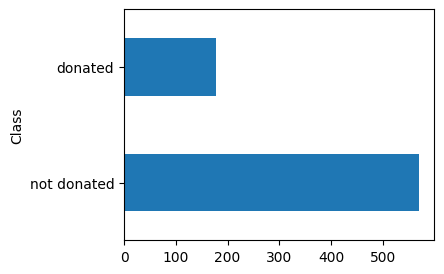

In [4]:
target.value_counts().plot.barh(figsize=(4, 3))

In [5]:
from sklearn.model_selection import train_test_split
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.5, random_state=0
)

In [6]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(data_train, target_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
model.predict(data_test)
model.score(data_test, target_test)

0.7780748663101604

In [8]:
np.mean(target_test == model.predict(data_test))

np.float64(0.7780748663101604)

In [9]:
from sklearn.metrics import accuracy_score
accuracy_score(target_test, model.predict(data_test))

0.7780748663101604

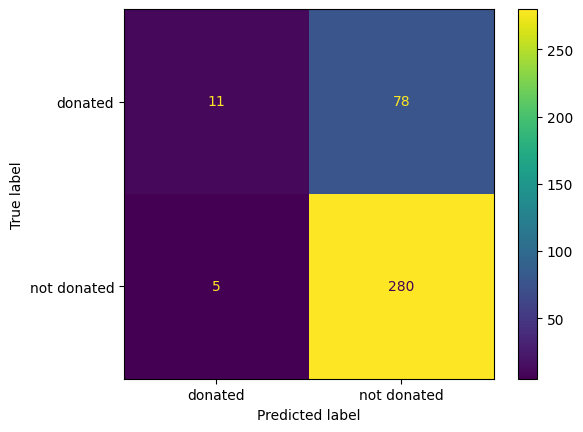

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, data_test, target_test)

In [11]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(target_test, model.predict(data_test), pos_label='donated')
recall = recall_score(target_test, model.predict(data_test), pos_label='donated')
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}")

Precision: 0.69, Recall: 0.12


In [12]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(data_train, target_train)
dummy.score(data_test, target_test)

0.7620320855614974

In [13]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score(target_test, model.predict(data_test))

0.5530258229844274

In [14]:
model_prob = pd.DataFrame(model.predict_proba(data_test), columns=model.classes_)
model_prob.head()

,donated,not donated
0,0.271818,0.728182
1,0.451765,0.548235
2,0.445210,0.554790
3,0.441577,0.558423
4,0.870588,0.129412


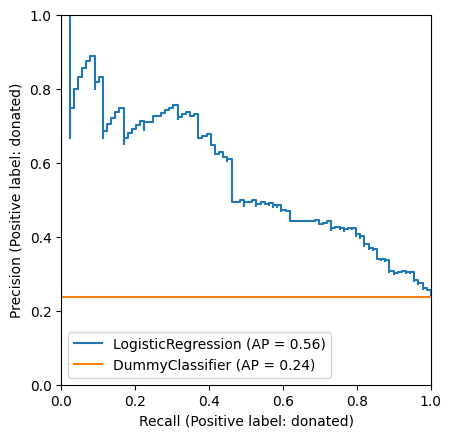

In [15]:
from sklearn.metrics import PrecisionRecallDisplay

disp = PrecisionRecallDisplay.from_estimator(
    model, data_test, target_test, pos_label='donated'
)
disp = PrecisionRecallDisplay.from_estimator(
    dummy, data_test, target_test, pos_label='donated', ax=disp.ax_
)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.savefig("j:/my drive/MyObsidian/images/precision_recall_curve.png", dpi=300)

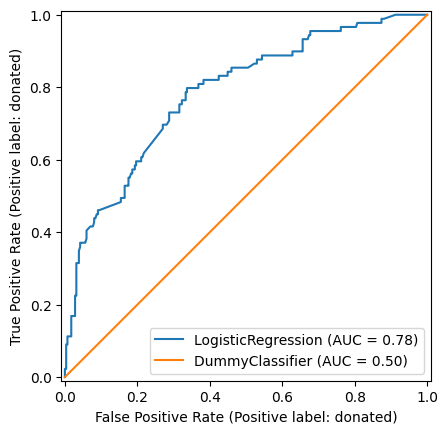

In [16]:
from sklearn.metrics import RocCurveDisplay

disp = RocCurveDisplay.from_estimator(
    model, data_test, target_test, pos_label='donated'
)
disp = RocCurveDisplay.from_estimator(
    dummy, data_test, target_test, pos_label='donated', ax=disp.ax_
)
plt.savefig("j:/my drive/MyObsidian/images/roc_curve.png", dpi=300)

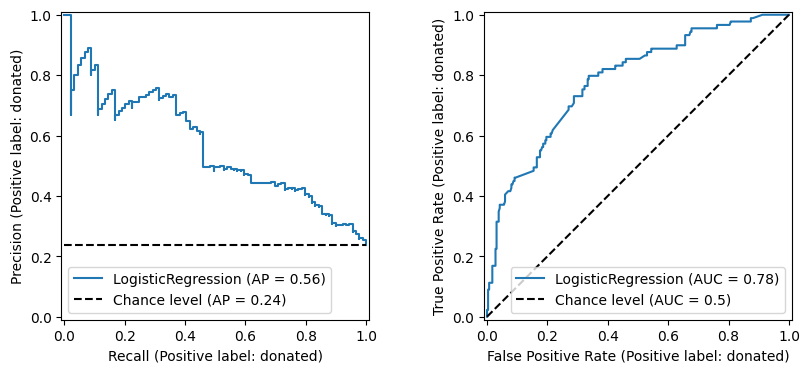

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
PrecisionRecallDisplay.from_estimator(
    model, data_test, target_test, pos_label='donated', 
    plot_chance_level=True,
    ax=axs[0]
)
RocCurveDisplay.from_estimator(
    model, data_test, target_test, pos_label='donated', 
    plot_chance_level=True,
    ax=axs[1]
)
plt.savefig("j:/my drive/MyObsidian/images/pr_and_roc_curves.png", dpi=300)

In [18]:
# Exercise M7.02
from sklearn.tree import DecisionTreeClassifier
model_tree = DecisionTreeClassifier(random_state=0)

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
scores = cross_val_score(
    model_tree, data, target, cv=cv, scoring='accuracy'
)
scores.mean()


np.float64(0.7097117117117115)

In [20]:
balanced_scores = cross_val_score(
    model_tree, data, target, cv=cv, scoring='balanced_accuracy'
)
balanced_scores.mean()

np.float64(0.5888974888200894)

In [21]:
# Converting the donated/not donated labels to 1/0 using scorer
from sklearn.metrics import make_scorer, precision_score, recall_score
precision_scorer = make_scorer(precision_score, pos_label='donated')
precision_scores = cross_val_score(
    model_tree, data, target, cv=cv, scoring=precision_scorer
)
precision_scores.mean()

np.float64(0.39471372152099704)

In [22]:
# Using cross_validate to compute both accuracy and balanced accuracy
from sklearn.model_selection import cross_validate
cv_results = cross_validate(
    model_tree, data, target, cv=cv,
    scoring=['accuracy', 'balanced_accuracy']
)

<Axes: >

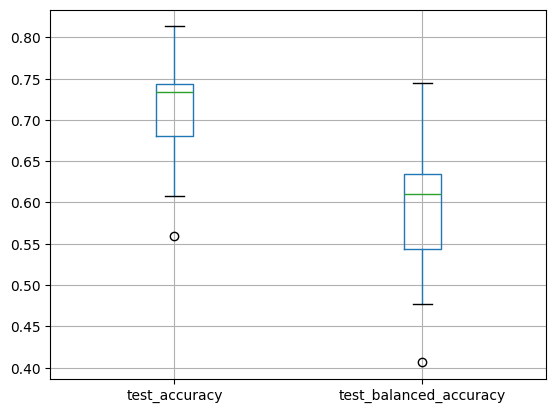

In [23]:
# Extract accuracy and balanced accuracy into a DataFrame
cv_results_df = pd.DataFrame(cv_results)[['test_accuracy', 'test_balanced_accuracy']]
cv_results_df.boxplot()

In [24]:
# Regression metrics
ames_housing = pd.read_csv("data/house_prices.csv")
data = ames_housing.drop(columns="SalePrice")
target = ames_housing["SalePrice"]
data = data.select_dtypes(np.number)
target /= 1000

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 34 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Id             1460 non-null   int64
 1   MSSubClass     1460 non-null   int64
 2   LotArea        1460 non-null   int64
 3   OverallQual    1460 non-null   int64
 4   OverallCond    1460 non-null   int64
 5   YearBuilt      1460 non-null   int64
 6   YearRemodAdd   1460 non-null   int64
 7   BsmtFinSF1     1460 non-null   int64
 8   BsmtFinSF2     1460 non-null   int64
 9   BsmtUnfSF      1460 non-null   int64
 10  TotalBsmtSF    1460 non-null   int64
 11  1stFlrSF       1460 non-null   int64
 12  2ndFlrSF       1460 non-null   int64
 13  LowQualFinSF   1460 non-null   int64
 14  GrLivArea      1460 non-null   int64
 15  BsmtFullBath   1460 non-null   int64
 16  BsmtHalfBath   1460 non-null   int64
 17  FullBath       1460 non-null   int64
 18  HalfBath       1460 non-null   int64
 19  Bedroo

In [26]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0
)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

regressor = LinearRegression()
regressor.fit(data_train, target_train)
target_pred = regressor.predict(data_train)

mean_squared_error(target_train, target_pred)

996.9015437480197

In [28]:
target_test_pred = regressor.predict(data_test)
mean_squared_error(target_test, target_test_pred)

2064.7358890625896

In [29]:
regressor.score(data_test, target_test)

0.687252058107552

In [30]:
from sklearn.dummy import DummyRegressor
dummy_regressor = DummyRegressor(strategy="mean")
dummy_regressor.fit(data_train, target_train)
dummy_regressor.score(data_test, target_test)

-8.569957818793661e-05

In [31]:
# mean absolute error
from sklearn.metrics import mean_absolute_error
mean_absolute_error(target_test, target_test_pred)

22.60801952240647

In [32]:
from sklearn.metrics import median_absolute_error
median_absolute_error(target_test, target_test_pred)

14.136575571228633

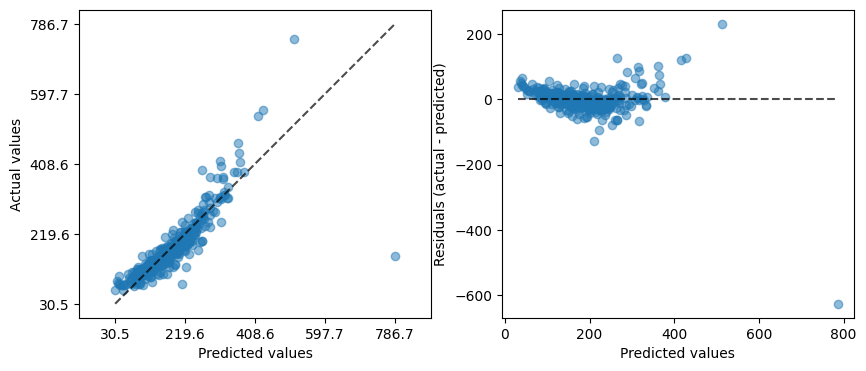

In [33]:
from sklearn.metrics import PredictionErrorDisplay

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
PredictionErrorDisplay.from_predictions(
    target_test, target_test_pred, 
    kind="actual_vs_predicted", 
    scatter_kwargs={'alpha': 0.5}, ax=ax[0])

PredictionErrorDisplay.from_predictions(
    target_test, target_test_pred,
    kind="residual_vs_predicted",
    scatter_kwargs={'alpha': 0.5}, ax=ax[1])
plt.savefig("j:/my drive/MyObsidian/images/prediction_error_display.png", dpi=300)

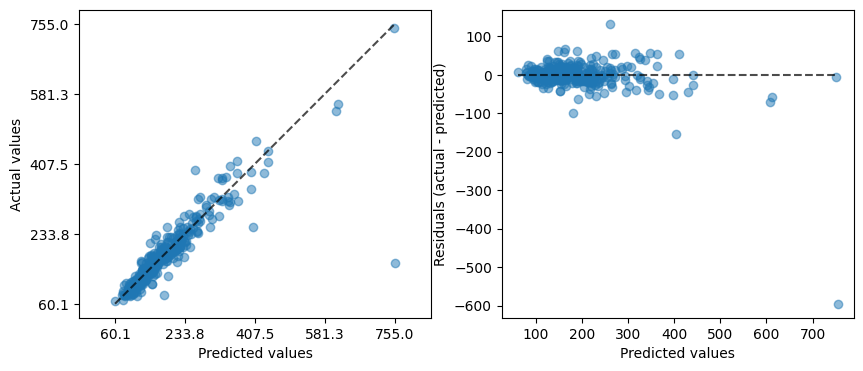

In [34]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import TransformedTargetRegressor

transformer = QuantileTransformer(n_quantiles=900, output_distribution='normal')
regressor_transformed = TransformedTargetRegressor(regressor=regressor, transformer=transformer)
regressor_transformed.fit(data_train, target_train)
target_test_pred_transformed = regressor_transformed.predict(data_test)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
PredictionErrorDisplay.from_predictions(
    target_test, target_test_pred_transformed, 
    kind="actual_vs_predicted", 
    scatter_kwargs={'alpha': 0.5}, ax=ax[0])

PredictionErrorDisplay.from_predictions(
    target_test, target_test_pred_transformed,
    kind="residual_vs_predicted",
    scatter_kwargs={'alpha': 0.5}, ax=ax[1])

In [35]:
# Exercise M7.03
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

In [36]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
cv = KFold(n_splits=10, shuffle=True, random_state=0)
scores = cross_val_score(
    regressor, data, target, cv=cv, scoring='r2'
)
scores.mean()

np.float64(0.7723973297408225)

In [37]:
from sklearn.metrics import mean_absolute_error
scores_mae = cross_val_score(
    regressor, data, target, cv=cv, scoring='neg_mean_absolute_error'
)
scores_mae = -scores_mae
scores_mae.mean()

np.float64(22.040837343833736)

In [38]:
from sklearn.model_selection import cross_validate

scores_all = cross_validate(
    regressor,
    data,
    target,
    cv=cv,
    scoring=['neg_mean_absolute_error', 'r2'],
    n_jobs=-1
)
scores_all_df = pd.DataFrame(scores_all)
scores_all_df[['test_neg_mean_absolute_error', 'test_r2']].mean()

test_neg_mean_absolute_error   -22.040837
test_r2                          0.772397
dtype: float64

In [39]:
# Wrap-up Quiz 7
import pandas as pd

cycling = pd.read_csv("data/bike_rides.csv", index_col=0,
                      parse_dates=True)
cycling.index.name = ""
target_name = "power"
data, target = cycling.drop(columns=target_name), cycling[target_name]
data

,heart-rate,cadence,speed,acceleration,slope
,,,,,
2020-08-18 14:43:19,102.0,64.0,4.325,0.0880,-0.033870
2020-08-18 14:43:20,103.0,64.0,4.336,0.0842,-0.033571
2020-08-18 14:43:21,105.0,66.0,4.409,0.0234,-0.033223
2020-08-18 14:43:22,106.0,66.0,4.445,0.0016,-0.032908
2020-08-18 14:43:23,106.0,67.0,4.441,0.1144,0.000000
...,...,...,...,...,...
2020-09-13 14:55:57,130.0,0.0,1.054,0.0234,0.000000
2020-09-13 14:55:58,130.0,0.0,0.829,0.0258,0.000000
2020-09-13 14:55:59,129.0,0.0,0.616,-0.1686,0.000000


In [40]:
target.head()


2020-08-18 14:43:19    150.0
2020-08-18 14:43:20    161.0
2020-08-18 14:43:21    163.0
2020-08-18 14:43:22    156.0
2020-08-18 14:43:23    148.0
Name: power, dtype: float64

In [41]:
# Create a new data_linear_model DataFrame with transformed features
data_linear_model = data['speed'].to_frame()
data_linear_model['speed_cubed'] = data_linear_model['speed'] ** 3
data_linear_model['sin angle'] = data_linear_model['speed'] *np.sin(np.arctan(data['slope']))

# clip acceleration to remove negative values
data_linear_model['speed x acceleration'] = data_linear_model['speed'] * data['acceleration'].clip(lower=0)
data_linear_model.head()

,speed,speed_cubed,sin angle,speed x acceleration
,,,,
2020-08-18 14:43:19,4.325,80.901828,-0.146402,0.380600
2020-08-18 14:43:20,4.336,81.520685,-0.145482,0.365091
2020-08-18 14:43:21,4.409,85.707790,-0.146398,0.103171
2020-08-18 14:43:22,4.445,87.824421,-0.146198,0.007112
2020-08-18 14:43:23,4.441,87.587538,0.000000,0.508050


In [42]:
data_linear_model['sin angle'].mean()

np.float64(-0.002709709612566326)

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_linear_model)

# Assess model performance with ShuffleSplit
from sklearn.model_selection import ShuffleSplit
ss = ShuffleSplit(n_splits=10, test_size=0.25, random_state=0)

from sklearn.model_selection import cross_validate

model = RidgeCV(alphas=np.logspace(-6, 6, 13))
scores = cross_validate(
    model, data_scaled, target, cv=ss,
    return_train_score=True,
    return_estimator=True,
    scoring='neg_mean_absolute_error')

In [44]:
scores

{'fit_time': array([0.02212667, 0.02282548, 0.02269769, 0.02416706, 0.02114201,
        0.0206039 , 0.02682734, 0.02565598, 0.02371287, 0.01997304]),
 'score_time': array([0.00073552, 0.00086141, 0.00087833, 0.00078249, 0.00073934,
        0.00073528, 0.00133181, 0.0011723 , 0.00108576, 0.00079298]),
 'estimator': [RidgeCV(alphas=array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01,
         1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06])),
  RidgeCV(alphas=array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01,
         1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06])),
  RidgeCV(alphas=array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01,
         1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06])),
  RidgeCV(alphas=array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01,
         1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06])),
  RidgeCV(alphas=array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01,
         1.e+02, 1.e+03, 1.e+04, 1.e+

In [45]:
scores['test_score'] = -scores['test_score']
scores['test_score'].mean()

np.float64(72.3695243815085)

In [46]:
scores['train_score'] = -scores['train_score']
scores['train_score'].mean()

np.float64(72.51898156961344)

In [47]:
# Extract coefficients of the best model
import numpy as np
best_model = scores['estimator'][scores['test_score'].argmin()]
coefficients = np.array(best_model.coef_)

# put coefficients in a Series for better visualization
feature_names = data_linear_model.columns

coefficients = pd.Series(coefficients, index=feature_names)
coefficients

speed                   32.108030
speed_cubed              6.080898
sin angle               80.069600
speed x acceleration    12.416622
dtype: float64

In [48]:
# fit a HistGradientBoostingRegressor model 
from sklearn.ensemble import HistGradientBoostingRegressor
model_gb = HistGradientBoostingRegressor(max_iter=1000, early_stopping=True)

scores_gb = cross_validate(
    model_gb, data, target, cv=ss, return_train_score=True, return_estimator=True, 
    scoring='neg_mean_absolute_error', n_jobs=-1)

scores_gb['test_score'] = -scores_gb['test_score']
scores_gb['test_score'].mean()


np.float64(44.24010173865352)

In [49]:
scores_gb['train_score'] = -scores_gb['train_score']
scores_gb['train_score'].mean()

np.float64(40.367067537358565)

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38254 entries, 2020-08-18 14:43:19 to 2020-09-13 14:56:01
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   heart-rate    38254 non-null  float64
 1   cadence       38254 non-null  float64
 2   speed         38254 non-null  float64
 3   acceleration  38254 non-null  float64
 4   slope         38254 non-null  float64
dtypes: float64(5)
memory usage: 1.8 MB


In [51]:
data.head()

,heart-rate,cadence,speed,acceleration,slope
,,,,,
2020-08-18 14:43:19,102.0,64.0,4.325,0.0880,-0.033870
2020-08-18 14:43:20,103.0,64.0,4.336,0.0842,-0.033571
2020-08-18 14:43:21,105.0,66.0,4.409,0.0234,-0.033223
2020-08-18 14:43:22,106.0,66.0,4.445,0.0016,-0.032908
2020-08-18 14:43:23,106.0,67.0,4.441,0.1144,0.000000


In [52]:
# Extract the date for the index
data['date'] = data.index.date
# check for the number of unique date values in the index
data['date'].nunique()

4

In [53]:
# Drop the date column to avoid data leakage
data = data.drop(columns='date')

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38254 entries, 2020-08-18 14:43:19 to 2020-09-13 14:56:01
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   heart-rate    38254 non-null  float64
 1   cadence       38254 non-null  float64
 2   speed         38254 non-null  float64
 3   acceleration  38254 non-null  float64
 4   slope         38254 non-null  float64
dtypes: float64(5)
memory usage: 1.8 MB


In [55]:
# LeaveOneGroupOut cross-validation
from sklearn.model_selection import LeaveOneGroupOut

# Create a group variable based on the date
group = cycling.index.date
group = pd.factorize(group)[0]
group

array([0, 0, 0, ..., 3, 3, 3])

In [ ]:
cv = LeaveOneGroupOut()
model_loo = HistGradientBoostingRegressor(max_iter=1000, early_stopping=True)
scores = cross_validate(
    model_loo, data, target, cv=cv, groups=group, return_train_score=True,
    scoring='neg_mean_absolute_error', n_jobs=-1)
scores['test_score'] = -scores['test_score']
scores['test_score'].mean()

np.float64(49.46827549012127)

In [58]:
scores['train_score'] = -scores['train_score']
scores['train_score'].mean()

np.float64(39.03982972055309)

In [59]:
model_linear = RidgeCV(alphas=np.logspace(-6, 6, 13))
scores_linear = cross_validate(
    model_linear, data, target, cv=cv, groups=group, return_train_score=True,
    scoring='neg_mean_absolute_error', n_jobs=-1)
scores_linear['test_score'] = -scores_linear['test_score']
scores_linear['test_score'].mean()

np.float64(64.72722446961417)

In [60]:
scores_linear['train_score'] = -scores_linear['train_score']
scores_linear['train_score'].mean()

np.float64(64.63249086056402)

In [62]:
cv = LeaveOneGroupOut()
train_indices, test_indices = list(cv.split(data, target, groups=group))[0]

data_linear_model_train = data_linear_model.iloc[train_indices]
data_linear_model_test = data_linear_model.iloc[test_indices]

data_train = data.iloc[train_indices]
data_test = data.iloc[test_indices]

target_train = target.iloc[train_indices]
target_test = target.iloc[test_indices]

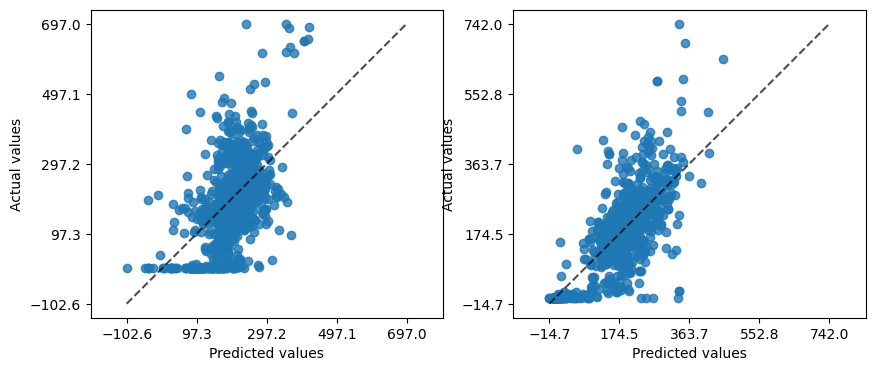

In [63]:
model_linear.fit(data_linear_model_train, target_train)
target_pred_linear = model_linear.predict(data_linear_model_test)

model_loo.fit(data_train, target_train)
target_pred_loo = model_loo.predict(data_test)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
PredictionErrorDisplay.from_predictions(
    target_test, target_pred_linear, kind="actual_vs_predicted", ax=ax[0])
PredictionErrorDisplay.from_predictions(
    target_test, target_pred_loo, kind="actual_vs_predicted", ax=ax[1])

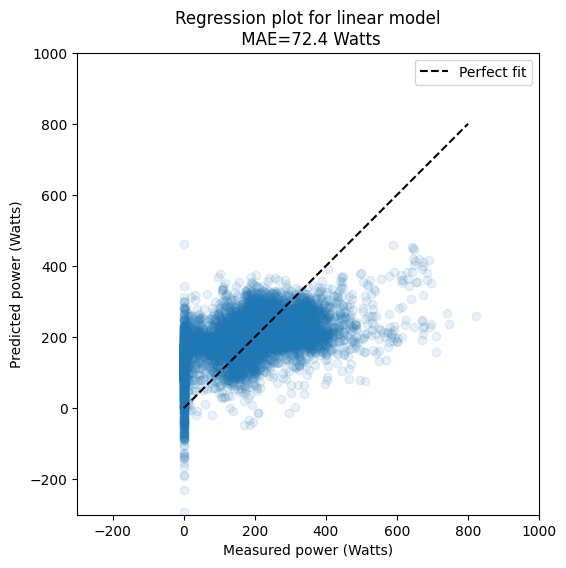

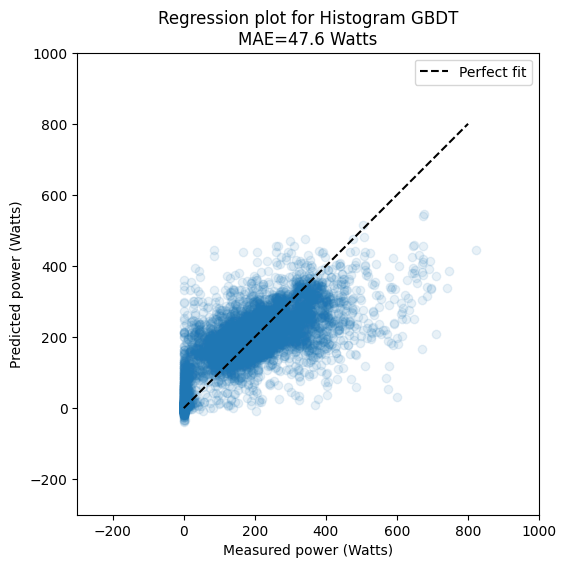

In [66]:
from sklearn.metrics import mean_absolute_error
linear_model = RidgeCV(alphas=np.logspace(-6, 6, 13))
hgbdt = HistGradientBoostingRegressor(max_iter=1000, early_stopping=True)

# fit models and collect predictions
linear_model.fit(data_linear_model_train, target_train)
target_predicted_linear_model = linear_model.predict(data_linear_model_test)

hgbdt.fit(data_train, target_train)
target_predicted_hgbdt = hgbdt.predict(data_test)

# compute errors
mae_linear_model = mean_absolute_error(target_test,
                                       target_predicted_linear_model)
mae_hgbdt = mean_absolute_error(target_test, target_predicted_hgbdt)

# make regression plots
plt.figure(figsize=(6, 6))
plt.scatter(target_test, target_predicted_linear_model, alpha=0.1)
plt.plot([0, 800], [0, 800], color="black", linestyle="--",
         label="Perfect fit")
plt.legend()
plt.axis("square")
plt.xlabel("Measured power (Watts)")
plt.ylabel("Predicted power (Watts)")
plt.xlim(-300, 1000)
plt.ylim(-300, 1000)
_ = plt.title(f"Regression plot for linear model\n "
              f"MAE={mae_linear_model:.1f} Watts")

plt.figure(figsize=(6, 6))
plt.scatter(target_test, target_predicted_hgbdt, alpha=0.1)
plt.plot([0, 800], [0, 800], color="black", linestyle="--",
         label="Perfect fit")
plt.legend()
plt.axis("square")
plt.xlabel("Measured power (Watts)")
plt.ylabel("Predicted power (Watts)")
plt.xlim(-300, 1000)
plt.ylim(-300, 1000)
_ = plt.title(f"Regression plot for Histogram GBDT\n"
              f"MAE={mae_hgbdt:.1f} Watts")

In [67]:
time_slice = slice("2020-08-18 17:00:00", "2020-08-18 17:05:00")

data_test_linear_model_subset = data_linear_model_test[time_slice]
data_test_subset = data_test[time_slice]
target_test_subset = target_test[time_slice]

In [68]:
# fit models and collect predictions
target_predicted_linear_model = linear_model.predict(data_test_subset)

target_predicted_hgbdt = hgbdt.predict(data_test_subset)

# compute errors
mae_linear_model = mean_absolute_error(target_test_subset,
                                       target_predicted_linear_model)
mae_hgbdt = mean_absolute_error(target_test_subset, target_predicted_hgbdt)

# make regression plots
plt.figure(figsize=(6, 6))
plt.scatter(target_test_subset, target_predicted_linear_model, alpha=0.1)
plt.plot([0, 800], [0, 800], color="black", linestyle="--",
         label="Perfect fit")
plt.legend()
plt.axis("square")
plt.xlabel("Measured power (Watts)")
plt.ylabel("Predicted power (Watts)")
plt.xlim(-300, 1000)
plt.ylim(-300, 1000)
_ = plt.title(f"Regression plot for linear model\n "
              f"MAE={mae_linear_model:.1f} Watts")

plt.figure(figsize=(6, 6))
plt.scatter(target_test_subset, target_predicted_hgbdt, alpha=0.1)
plt.plot([0, 800], [0, 800], color="black", linestyle="--",
         label="Perfect fit")
plt.legend()
plt.axis("square")
plt.xlabel("Measured power (Watts)")
plt.ylabel("Predicted power (Watts)")
plt.xlim(-300, 1000)
plt.ylim(-300, 1000)
_ = plt.title(f"Regression plot for Histogram GBDT\n"
              f"MAE={mae_hgbdt:.1f} Watts")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- acceleration
- cadence
- heart-rate
- slope
Feature names seen at fit time, yet now missing:
- sin angle
- speed x acceleration
- speed_cubed
